In [17]:
import sys
from pathlib import Path
PROJECT_ROOT = Path(sys.prefix).parent
%cd {PROJECT_ROOT}

/home/younes/younes/Projects/Python/barid_internship


In [18]:
import warnings

warnings.filterwarnings("ignore")
import os

os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np

np.set_printoptions(suppress=True)
np.random.seed(1)
import random

random.seed(1)
import pandas as pd

pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns

sns.set_style("whitegrid")
import matplotlib.pyplot as plt

plt.style.use("ggplot")
plt.rcParams.update(
    {
        "figure.figsize": (8, 5),
        "figure.dpi": 100,
        "savefig.dpi": 300,
        "figure.constrained_layout.use": True,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "legend.title_fontsize": 10,
        "grid.alpha": 1.0,
    }
)
import matplotlib as mpl
from cycler import cycler

mpl.rcParams["axes.prop_cycle"] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name="black_and_2color",
    ),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name="black_and_3color",
    ),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name="black_and_4color",
    ),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name="r_colors",
    ),
    force=True,
)

In [19]:
import polars as pl
import altair as alt

# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
from functools import partial
from fpppy.utils import plot_series, plot_series_stacked, plot_diagnostics
from utilsforecast.plotting import plot_series as plot_series_utils
from utilsforecast.evaluation import evaluate
from statsforecast.utils import ConformalIntervals
from utilsforecast.losses import mase, rmsse, rmae, spis, nd
from coreforecast.scalers import boxcox, inv_boxcox, boxcox_lambda
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive
from mlforecast import MLForecast
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import (
    LinearRegression,
    ElasticNet,
    ARDRegression,
    TweedieRegressor,
    Ridge,
    Lasso,
)
from sklearn.ensemble import HistGradientBoostingRegressor
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.utils import aggregate
from hierarchicalforecast.methods import BottomUp, TopDown, MinTrace
from utilsforecast.feature_engineering import trend, fourier, pipeline
from typing import Callable, Literal, Any, Mapping, Optional, Iterable, Sequence
from polars._typing import IntoExpr

# import calendar

# from scipy.stats import pearsonr
# from plotly import express as px
# from pathlib import Path
# from itertools import chain
from datetime import date, timedelta
from itertools import product

import importlib
import lib
import read_data

importlib.reload(lib)

cfg = pl.Config()
cfg.set_tbl_width_chars(10000)
cfg.set_fmt_str_lengths(100)
cfg.set_tbl_cols(-1)
cfg.set_tbl_rows(10)

alt.data_transformers.enable("vegafusion")

DataTransformerRegistry.enable('vegafusion')

In [20]:
gregorian_year_days = int(365.25)
gregorian_year_weeks = int(gregorian_year_days / 7)
hijri_year_days = int(354.37)
hijri_year_weeks = 51

In [21]:
cabs_inter = set(read_data.read_smi_envoisbyproduitintern_many()["codeenvoi_"])

In [22]:
fields = (
    pl.read_parquet("data/cab_dfs/fields.parquet")
    .filter(Etat="V")
    .filter(pl.col("Cab").is_in(cabs_inter))
    .filter(pl.col("Date_depot").ge(pl.date(2023, 1, 1)))
    .cast({"Id": pl.String})
    .sort("Date_depot")
    .rename({"Poids_global_en_KG": "weight_kg"})
    .drop_nulls("weight_kg")
)

In [23]:
importlib.reload(lib)
base_df = (
    fields
    # .pipe(lib.top_n_or_other, "Centre_Agence_depot", 10, "other_agence")
    # .pipe(lib.top_n_or_other, "Destination", 10, "other_dist")
    .pipe(lib.top_n_or_other, "Centre_Agence_depot", 10)
    .pipe(lib.top_n_or_other, "Destination", 10)
    .with_columns(total=pl.lit("total"))
    .pipe(
        lib.aggregate_by_date,
        freq="7d",
        value_col="weight_kg",
        date_col="Date_depot",
        total_col="total_weight_kg",
        count_col="count",
        mean_col="mean_weight_kg",
        std_col="std_weight_kg",
        # extra_cols=lib.make_relative_hist_cols(
        #     "weight_kg", list(range(32)) + [np.inf], "sum"
        # ),
        group_cols=["Centre_Agence_depot", "Destination", "total"],
    )
)

root_base_df = fields.pipe(
    lib.aggregate_by_date,
    freq="7d",
    value_col="weight_kg",
    date_col="Date_depot",
    total_col="total_weight_kg",
    count_col="count",
    mean_col="mean_weight_kg",
    std_col="std_weight_kg",
    # extra_cols=lib.make_relative_hist_cols(
    #     "weight_kg", list(range(32)) + [np.inf], "sum"
    # ),
)

# chart = (
#     alt.Chart(base_df)
#     .mark_line(point=True)
#     .encode(
#         x="Date_depot:T",
#         y=alt.Y("count:Q", scale=alt.Scale(zero=False)),
#         tooltip=["Date_depot:T"],
#     )
#     .properties(width=1100, title="Weekly Mean Weight")
# )
# chart

In [24]:
def transform_timeseries(
    df: pl.DataFrame,
    cols: IntoExpr | Iterable[IntoExpr] = "y",
) -> pl.DataFrame:
    cols_exprs = lib.as_exprs(cols)
    return df.with_columns([col.log1p() for col in cols_exprs])


def untransform_timeseries(
    df: pl.DataFrame,
    cols: IntoExpr | Iterable[IntoExpr] = pl.exclude("unique_id", "ds"),
) -> pl.DataFrame:
    cols_exprs = lib.as_exprs(cols)
    return df.with_columns([col.exp() - 1 for col in cols_exprs])


def calculate_max_n_windows(N, h, season_length, step_size):
    return (N - h - season_length - 1) // step_size


def fake_grouped_fc(
    root_fc: pl.DataFrame,
    grouped_Y_df: pl.DataFrame,
) -> pl.DataFrame:

    return root_fc.pipe(
        lib.complete_grid,
        dimensions={
            "unique_id": grouped_Y_df["unique_id"].unique(),
            "ds": root_fc["ds"].sort().unique(),
        },
        fill_value=0,
    )


def reconcile_forecast(
    root_fc: pd.DataFrame,
    Y_df: pl.DataFrame,
    S_df: pl.DataFrame,
    tags: dict[str, np.ndarray],
):
    raw_fc = pl.DataFrame(
        root_fc,
        schema_overrides={"ds": pl.Date},
    ).pipe(fake_grouped_fc, Y_df)

    recon = HierarchicalReconciliation(reconcilers=[TopDown("proportion_averages")])

    fc = recon.reconcile(
        Y_hat_df=raw_fc.to_pandas(),  # pyright: ignore[reportArgumentType]
        Y_df=Y_df.to_pandas(),  # pyright: ignore[reportArgumentType]
        S_df=S_df.to_pandas(),  # pyright: ignore[reportArgumentType]
        tags=tags,
    )

    return pl.DataFrame(fc)


def unnest_grouped_unique_id(
    df: pl.DataFrame,
    categories: Sequence[str],
) -> pl.DataFrame:
    return (
        df.filter(
            pl.col("unique_id").str.count_matches("/", literal=True) == len(categories)
        )
        .select(
            pl.col("unique_id")
            .str.extract_groups("^.+?/" + "/".join(len(categories) * ["(.+?)"]) + "$")
            .struct.rename_fields(categories)
            .struct.unnest(),
            pl.all(),
        )
        .drop("unique_id")
    )


def with_totals(
    df: pl.DataFrame,
    categories: Sequence[str],
    value_cols: IntoExpr | Iterable[IntoExpr] = pl.selectors.all(),
) -> pl.DataFrame:
    value_cols_exprs = lib.as_exprs(value_cols)

    return (
        pl.concat(
            df.with_columns(
                **{
                    col: pl.lit("all")
                    for col, use_all in zip(categories, mask)
                    if use_all
                }
            )
            for mask in product([True, False], repeat=len(categories))
        )
        .group_by(["ds", "Destination", "Centre_Agence_depot"], maintain_order=True)
        .agg(
            *[value_col.sum() for value_col in value_cols_exprs],
            # pl.selectors.exclude(value_cols_exprs).first(),  # requires the specialized Selector class, not any normal Expr
        )
    )


def sort_by_categories(df: pl.DataFrame, categories: Sequence[str]) -> pl.DataFrame:
    return df.sort(
        [
            pl.when(pl.col(category) == "all")
            .then(0)
            .when(pl.col(category) == "other")
            .then(2)
            .otherwise(1)
            for category in categories
        ]
        # + [pl.col(category) for category in categories]
    )


def clip_horizon(df: pl.DataFrame, h: int = 4, date_col: str = "ds") -> pl.DataFrame:
    return df.filter(pl.col(date_col).is_in(pl.col(date_col).unique().sort().head(h)))

In [29]:
root_Y_df, root_X_df = (
    root_base_df.select(
        ds=pl.col("Date_depot"),
        y=pl.col("count"),
        unique_id=pl.lit("total"),
    )
    .pipe(transform_timeseries)
    .pipe(
        pipeline,
        [
            trend,
            # partial(fourier, season_length=52, k=5),
        ],
        "1w",
        4,
    )
)


levels: list[int] = [80, 95]
h = 4
# intervals_daily = ConformalIntervals(h=h, n_windows=min(10, len(df_daily) // h))
intervals = ConformalIntervals(h=h, n_windows=10)
cv_step_size = 10
# cv_n_windows_daily = calculate_max_n_windows(
#     len(df_daily), h, hijri_year_weeks, cv_step_size
# )
# cv_n_windows = calculate_max_n_windows(len(df), h, hijri_year_weeks, cv_step_size)
cv_n_windows = 10

In [30]:
sf = StatsForecast(
    freq="1w",
    n_jobs=-1,
    models=[
        SeasonalNaive(
            season_length=hijri_year_weeks,
            # prediction_intervals=intervals, # buggy
        ),
    ],
)

In [31]:
fcst = MLForecast(
    models=[
        LinearRegression(),
        ElasticNet(),
        ARDRegression(),
        TweedieRegressor(),
        Lasso(),
        Ridge(),
        #
        HistGradientBoostingRegressor(),
        LGBMRegressor(random_state=1, verbosity=-1),
        XGBRegressor(random_state=1),
        CatBoostRegressor(
            random_state=1, verbose=False
        ),  # pyright: ignore[reportArgumentType]
    ],
    freq=pd.infer_freq(
        root_Y_df.to_pandas()["ds"]
    ),  # pyright: ignore[reportArgumentType]
    lags=[1, 2, 3, 4, hijri_year_weeks],
    # date_features=[
    #     "year",
    #     "month",
    #     "quarter",
    #     "week",
    # ],
)

In [32]:
fcst.fit(
    df=root_Y_df.to_pandas(),
    # prediction_intervals=intervals,
    static_features=[],
)  # pyright: ignore[reportArgumentType]

MLForecast(models=[LinearRegression, ElasticNet, ARDRegression, TweedieRegressor, Lasso, Ridge, HistGradientBoostingRegressor, LGBMRegressor, XGBRegressor, CatBoostRegressor], freq=W-THU, lag_features=['lag1', 'lag2', 'lag3', 'lag4', 'lag51'], date_features=[], num_threads=1)

In [33]:
root_fc = fcst.predict(
    h=100,
    X_df=root_X_df.to_pandas(),
    # level=levels,
)  # pyright: ignore[reportAssignmentType]

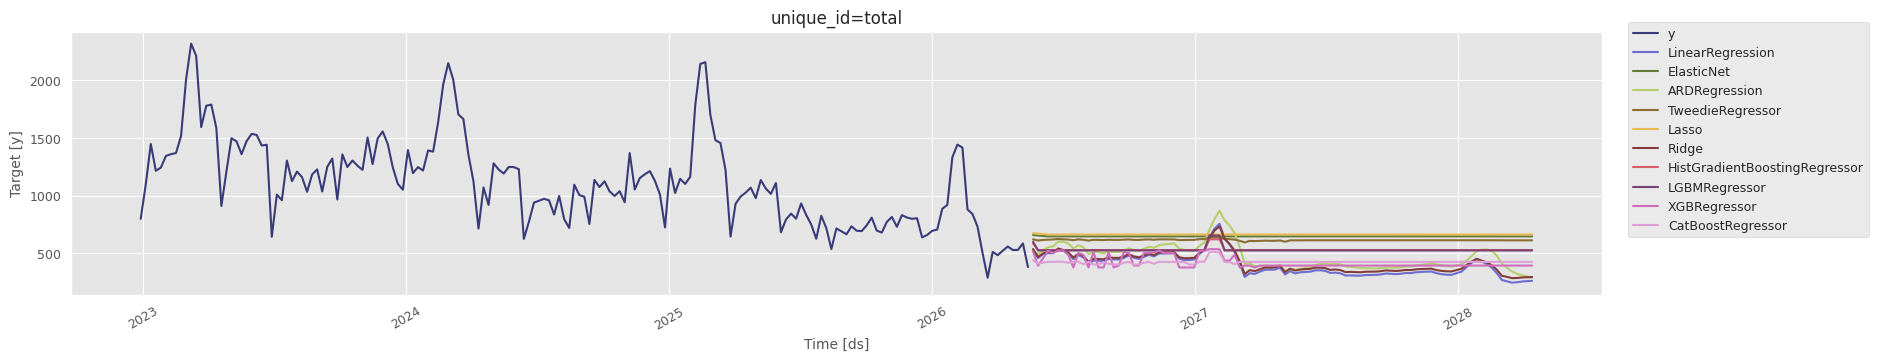

In [34]:
StatsForecast.plot(
    root_Y_df.pipe(untransform_timeseries).to_pandas(),
    pl.DataFrame(root_fc).pipe(untransform_timeseries).to_pandas(),
    # level=levels,  # pyright: ignore[reportArgumentType]
)

In [36]:
baseline_cv_df = sf.cross_validation(
    h=h,
    df=root_Y_df.to_pandas(),
    n_windows=10,
    step_size=cv_step_size,
    # level=levels,
)

cv_df = fcst.cross_validation(
    h=h,
    df=root_Y_df.to_pandas(),
    static_features=[],
    n_windows=10,
    step_size=cv_step_size,
    # level=levels,
)

cv_df["SeasonalNaive"] = baseline_cv_df["SeasonalNaive"]

transformed_cv_df = pl.DataFrame(cv_df).pipe(
    untransform_timeseries,
    pl.exclude("unique_id", "ds", "cutoff"),
)

In [37]:
transformed_cv_df = transformed_cv_df.with_columns(
    ml_ensemble=(pl.col("Ridge") + pl.col("CatBoostRegressor")) / 2
)

cv_evaluation = evaluate(
    transformed_cv_df.to_pandas(),
    train_df=root_Y_df.to_pandas(),
    metrics=[
        partial(mase, seasonality=hijri_year_weeks),
        partial(rmae, baseline="SeasonalNaive"),
        spis,
        nd,
    ],
    # level=levels,
)
print(pl.DataFrame(cv_evaluation))

shape: (40, 15)
┌───────────┬─────────────────────┬────────┬──────────────────┬─────────────┬───────────────┬──────────────────┬─────────────┬────────────┬───────────────────────────────┬───────────────┬──────────────┬───────────────────┬───────────────┬─────────────┐
│ unique_id ┆ cutoff              ┆ metric ┆ LinearRegression ┆ ElasticNet  ┆ ARDRegression ┆ TweedieRegressor ┆ Lasso       ┆ Ridge      ┆ HistGradientBoostingRegressor ┆ LGBMRegressor ┆ XGBRegressor ┆ CatBoostRegressor ┆ SeasonalNaive ┆ ml_ensemble │
│ ---       ┆ ---                 ┆ ---    ┆ ---              ┆ ---         ┆ ---           ┆ ---              ┆ ---         ┆ ---        ┆ ---                           ┆ ---           ┆ ---          ┆ ---               ┆ ---           ┆ ---         │
│ str       ┆ datetime[ms]        ┆ str    ┆ f64              ┆ f64         ┆ f64           ┆ f64              ┆ f64         ┆ f64        ┆ f64                           ┆ f64           ┆ f64          ┆ f64               ┆ f6

In [38]:
print(
    pl.DataFrame(cv_evaluation)
    .group_by("metric")
    .agg(pl.exclude("unique_id", "cutoff", "metric").mean())
    .unpivot(index="metric", variable_name="model", value_name="score")
    .sort("metric", "score")
    .filter(metric="rmae_SeasonalNaive")
)

shape: (12, 3)
┌────────────────────┬───────────────────┬──────────┐
│ metric             ┆ model             ┆ score    │
│ ---                ┆ ---               ┆ ---      │
│ str                ┆ str               ┆ f64      │
╞════════════════════╪═══════════════════╪══════════╡
│ rmae_SeasonalNaive ┆ ml_ensemble       ┆ 0.384741 │
│ rmae_SeasonalNaive ┆ Ridge             ┆ 0.403761 │
│ rmae_SeasonalNaive ┆ LinearRegression  ┆ 0.414523 │
│ rmae_SeasonalNaive ┆ CatBoostRegressor ┆ 0.436181 │
│ rmae_SeasonalNaive ┆ ARDRegression     ┆ 0.484332 │
│ …                  ┆ …                 ┆ …        │
│ rmae_SeasonalNaive ┆ LGBMRegressor     ┆ 0.595673 │
│ rmae_SeasonalNaive ┆ TweedieRegressor  ┆ 0.643977 │
│ rmae_SeasonalNaive ┆ ElasticNet        ┆ 0.685479 │
│ rmae_SeasonalNaive ┆ Lasso             ┆ 0.745938 │
│ rmae_SeasonalNaive ┆ SeasonalNaive     ┆ 1.0      │
└────────────────────┴───────────────────┴──────────┘


In [39]:
long_df = pl.DataFrame(cv_evaluation).unpivot(
    index=["unique_id", "cutoff", "metric"],
    on=pl.selectors.exclude(["unique_id", "cutoff", "metric"]),
    variable_name="model",
    value_name="value",
)
# .filter(model)

chart = (
    alt.Chart(long_df.to_pandas())
    .mark_line(point=True)
    .encode(
        x=alt.X("cutoff:T", title="Cutoff"),
        y=alt.Y("value:Q", title="RMAE"),
        color=alt.Color("model:N", title="Model"),
        tooltip=["cutoff:T", "model:N", "value:Q"],
    )
    .properties(
        width=800, height=400, title="RMAE over Cross-validation windows by model"
    )
)

chart = lib.add_dropdown_filter(chart, long_df, "metric")

chart

alt.Chart(...)

In [ ]:
# pl.DataFrame(cv_evaluation).write_csv("results/ml_cv_evaluation.csv")

In [41]:
# pl.DataFrame(root_fc).write_csv("results/ml_root_fc_h_4.csv")

In [42]:
# pl.DataFrame(root_fc).write_csv("results/ml_root_fc_h_100_weight.csv")